In [3]:
import sys

# sanity check: print path to the Python binary (should be something like /home/jhehli/env/bin/python)
print(sys.executable) 

/home/jhehli/env/bin/python


In [1]:
import numpy as np 
import pandas as pd 
import os
from matplotlib import pyplot as plt
import torch
from PIL import Image

# installed in env
# !pip install git+https://github.com/facebookresearch/segment-anything.git

In [4]:
print("cuda available: ", torch.cuda.is_available())
print("cuda device count: ", torch.cuda.device_count())
print("cuda devices: ", [torch.device(f'cuda:{i}')
      for i in range(torch.cuda.device_count())])

cuda available:  True
cuda device count:  8
cuda devices:  [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3), device(type='cuda', index=4), device(type='cuda', index=5), device(type='cuda', index=6), device(type='cuda', index=7)]


In [6]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "/data/jhehli/model_checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"

device = "cuda:0"

sam_model = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam_model.to(device=device)
print()

In [7]:
image = Image.open('/data/jhehli/png_images/20250811_Dani_Vegetariana_Site of interest (2)_Bottom.png')
image = image.resize((512, 512))
image_arr = np.array(image)
print(image_arr.shape, image.mode)

if image_arr.ndim == 2:
    image_arr = np.repeat(image_arr[:, :, None], 3, axis=2)
elif image_arr.shape[2] == 1:
    image_arr = np.repeat(image_arr, 3, axis=2)

print(image_arr.shape)


(512, 512) L
(512, 512, 3)


# Zero-Shot Inference without Prompts (SamAutomaticMaskGenerator)

In [8]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)  

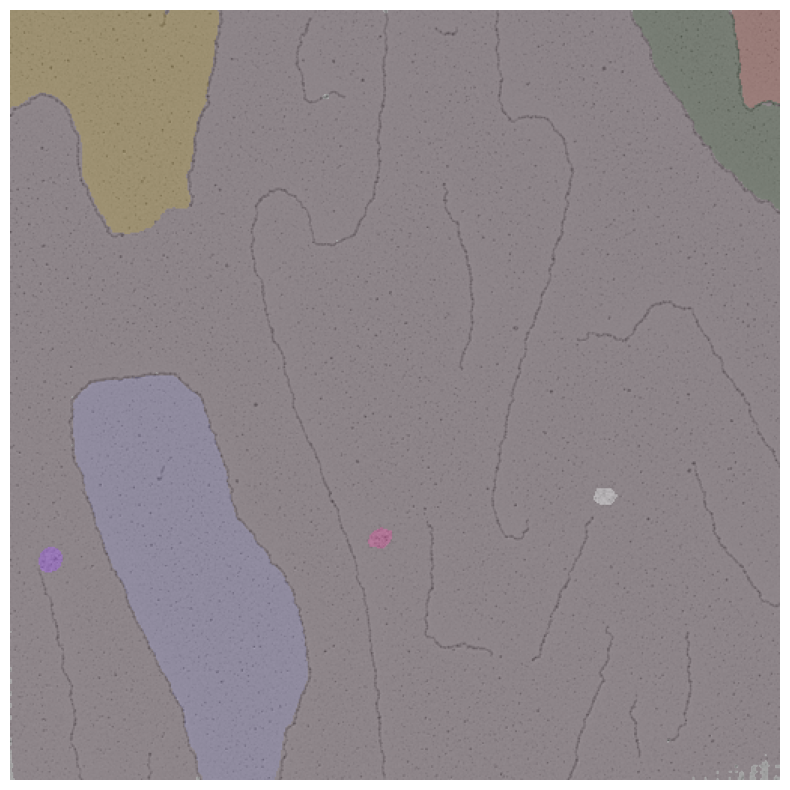

In [9]:
mask_generator = SamAutomaticMaskGenerator(sam_model)
masks = mask_generator.generate(image_arr)

plt.figure(figsize=(10,10))
plt.imshow(image_arr)
show_anns(masks)
plt.axis('off')
plt.show() 

# Zero-Shot Inference with Prompts

In [10]:

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))   

In [11]:
predictor = SamPredictor(sam_model)
predictor.set_image(image_arr)

## Bounding Box Prompts

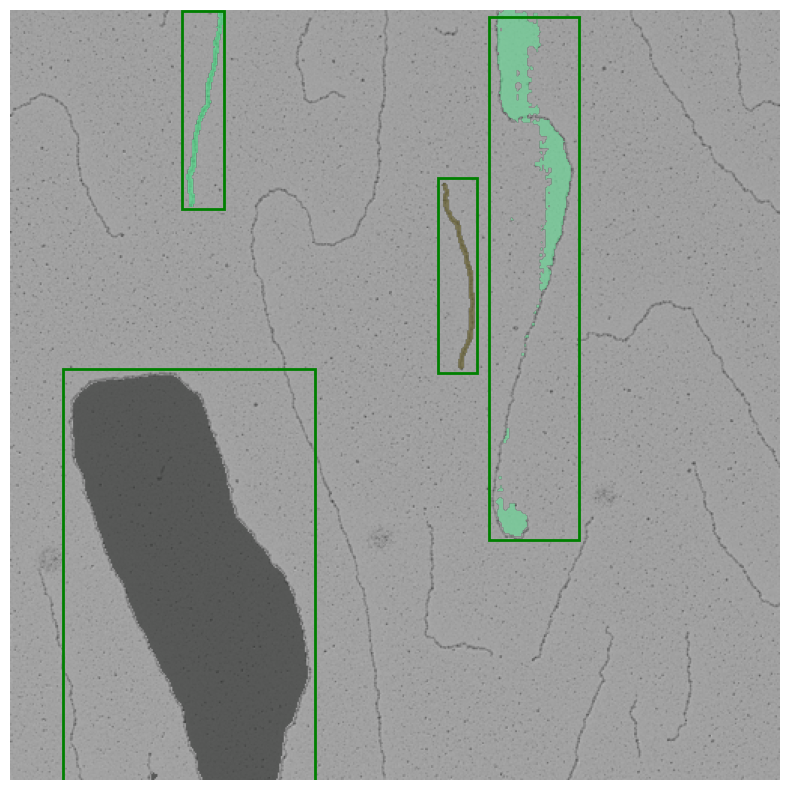

In [12]:
input_boxes = torch.tensor([
    [318, 4, 378, 352],
    [284, 111, 310, 241],
    [114, 0, 142,132],
    [35, 238, 202, 512]
], device=predictor.device)
transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, image_arr.shape[:2])

masks, _, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=False,
)

plt.figure(figsize=(10, 10))
plt.imshow(image_arr)
for mask in masks:
    show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box.cpu().numpy(), plt.gca())
plt.axis('off')
plt.show()


## Bounding Box + Point Prompt

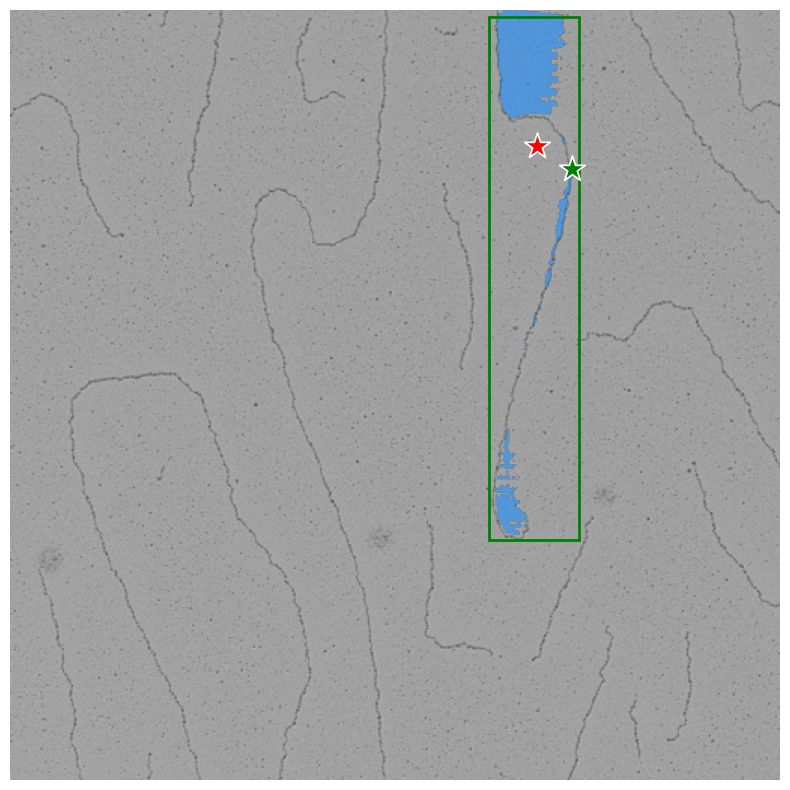

In [13]:
input_box = np.array([318, 4, 378, 352],)
input_point = np.array([[373, 105], [350, 90]])
input_label = np.array([1, 0])

masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)

plt.figure(figsize=(10, 10))
plt.imshow(image_arr)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()